In [ ]:
from google.colab import drive
drive.mount('/content/drive'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path

# Dataset path (shared shortcut — read only, for data only)
DRIVE_BASE = "/content/drive/MyDrive/ColabNotebooks/DLP Project Datasets"

# Checkpoint path (YOUR Drive — writable)
CKPT_DIR = Path("/content/drive/MyDrive/ColabNotebooks/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Test writable
test = CKPT_DIR / "write_test.txt"
try:
    test.write_text("test")
    test.unlink()
    print(f"✅ Checkpoint dir writable: {CKPT_DIR}")
except Exception as e:
    print(f"❌ Not writable: {e}")

print("\nDataset exists:", os.path.exists(DRIVE_BASE))
print("Dataset contents:", os.listdir(DRIVE_BASE))

✅ Checkpoint dir writable: /content/drive/MyDrive/ColabNotebooks/checkpoints

Dataset exists: True
Dataset contents: ['Look Into Person', 'DeepFashion', 'checkpoints']


In [ ]:
import zipfile, os

DRIVE_BASE = "/content/drive/MyDrive/ColabNotebooks/DLP Project Datasets"

datasets = [
    (f'{DRIVE_BASE}/DeepFashion/Img/img.zip',               '/content/deepfashion/img/'),
    (f'{DRIVE_BASE}/DeepFashion/img_highres_seg.zip',        '/content/deepfashion/seg/'),
    (f'{DRIVE_BASE}/Look Into Person/TrainVal_images/TrainVal_images.zip',
                                                             '/content/lip/images/'),
    (f'{DRIVE_BASE}/Look Into Person/TrainVal_parsing_annotations/TrainVal_parsing_annotations.zip',
                                                             '/content/lip/annotations/'),
]

for zip_path, extract_to in datasets:
    if not os.path.exists(zip_path):
        print(f"⚠️  ZIP not found, skipping: {zip_path}")
        continue
    sentinel = os.path.join(extract_to, '.done')
    if not os.path.exists(sentinel):
        os.makedirs(extract_to, exist_ok=True)
        print(f"Unzipping {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_to)
        open(sentinel, 'w').close()
        print(f"✅ Done → {extract_to}")
    else:
        print(f"✅ Already extracted: {extract_to}")

✅ Already extracted: /content/deepfashion/img/
✅ Already extracted: /content/deepfashion/seg/
✅ Already extracted: /content/lip/images/
✅ Already extracted: /content/lip/annotations/


In [ ]:
!pip install -q diffusers transformers accelerate ftfy Pillow tqdm
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done


In [ ]:
import os

if not os.path.exists('/content/Luxe'):
    !git clone https://github.com/nabirakhan/luxe /content/Luxe
    print("✅ Repo cloned")
else:
    print("✅ Repo already exists")

✅ Repo already exists


In [ ]:
import os
from pathlib import Path

DRIVE_BASE = "/content/drive/MyDrive/ColabNotebooks/DLP Project Datasets"
CKPT_DIR   = Path("/content/drive/MyDrive/ColabNotebooks/checkpoints")

# Auto detect correct image root
if Path("/content/deepfashion/img/img").exists():
    IMG_ROOT = "/content/deepfashion/img/img"
else:
    IMG_ROOT = "/content/deepfashion/img"

checks = {
    "Dataset base":      DRIVE_BASE,
    "DeepFashion":       f"{DRIVE_BASE}/DeepFashion",
    "InShop file":       f"{DRIVE_BASE}/DeepFashion/list_item_inshop.txt",
    "Images unzipped":   IMG_ROOT,
    "Checkpoint dir":    str(CKPT_DIR),
    "Repo backend":      "/content/Luxe/backend",
    "utils.py":          "/content/Luxe/backend/utils.py",
}

all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    print(f"{status}  {name}: {path}")
    if not exists:
        all_ok = False

# Count images
total = sum(1 for _ in Path(IMG_ROOT).rglob("*.jpg"))
print(f"\n📸 Total images: {total}")
print("\n✅ Ready to train!" if all_ok else "\n❌ Fix missing items above")

✅  Dataset base: /content/drive/MyDrive/ColabNotebooks/DLP Project Datasets
✅  DeepFashion: /content/drive/MyDrive/ColabNotebooks/DLP Project Datasets/DeepFashion
✅  InShop file: /content/drive/MyDrive/ColabNotebooks/DLP Project Datasets/DeepFashion/list_item_inshop.txt
✅  Images unzipped: /content/deepfashion/img/img
✅  Checkpoint dir: /content/drive/MyDrive/ColabNotebooks/checkpoints
✅  Repo backend: /content/Luxe/backend
✅  utils.py: /content/Luxe/backend/utils.py

📸 Total images: 52712

✅ Ready to train!


📁 Using nested img root: /content/deepfashion/img/img
✅ GPU: Tesla T4
✅ Memory: 15.6GB

📁 Building pairs from folder structure...
✅ 44730 pairs from 7982 items
   Sample A: /content/deepfashion/img/img/MEN/Denim/id_00000080/01_1_front.jpg
   Sample B: /content/deepfashion/img/img/MEN/Denim/id_00000080/01_2_side.jpg
✅ DataLoader ready — 11183 batches per epoch

⬇️  Loading CLIP...
✅ CLIP loaded
⬇️  Loading VAE...


✅ VAE loaded
🔄 Found checkpoint on Drive
🔄 Epoch 2 was complete
   Starting epoch 3, best_loss=0.00003

📊 Will train epochs 3 to 3

🚀 Starting training...


Epoch 3/3:   0%|          | 0/11183 [00:00<?, ?it/s]

  💾+☁️ checkpoint saved at step 500
  💾+☁️ checkpoint saved at step 1000
  💾+☁️ checkpoint saved at step 1500
  💾+☁️ checkpoint saved at step 2000
  💾+☁️ checkpoint saved at step 2500
  💾+☁️ checkpoint saved at step 3000
  💾+☁️ checkpoint saved at step 3500
  💾+☁️ checkpoint saved at step 4000
  💾+☁️ checkpoint saved at step 4500
  💾+☁️ checkpoint saved at step 5000
  💾+☁️ checkpoint saved at step 5500
  💾+☁️ checkpoint saved at step 6000
  💾+☁️ checkpoint saved at step 6500
  💾+☁️ checkpoint saved at step 7000
  💾+☁️ checkpoint saved at step 7500
  💾+☁️ checkpoint saved at step 8000
  💾+☁️ checkpoint saved at step 8500
  💾+☁️ checkpoint saved at step 9000
  💾+☁️ checkpoint saved at step 9500
  💾+☁️ checkpoint saved at step 10000
  💾+☁️ checkpoint saved at step 10500
  💾+☁️ checkpoint saved at step 11000
Epoch 3/3  avg_loss=0.00002
  🎯 New best loss: 0.00002
  💾+☁️ checkpoint saved at end of epoch 3
  ✅ ipp_proj_epoch3.pth saved locally + Drive


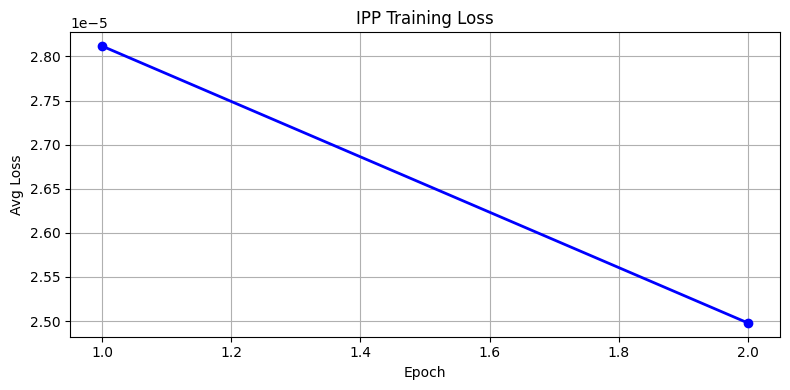

  📈 Loss curve saved
  🟡 Loss plateau (0.000003 drop) — watch next epoch

💾 Saving final weights...
  ✅ ip_adapter.pth saved locally + Drive
✅ ipp_vae.pth saved locally + Drive

🎉 Training complete!
📁 Local:  /content/checkpoints
☁️  Drive:  /content/drive/MyDrive/ColabNotebooks/checkpoints
📊 Final loss history: [3e-05, 2e-05]


In [ ]:
import sys, os, shutil, json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_BASE     = "/content/drive/MyDrive/ColabNotebooks/DLP Project Datasets"
DRIVE_CKPT_DIR = Path("/content/drive/MyDrive/ColabNotebooks/checkpoints")
LOCAL_CKPT_DIR = Path("/content/checkpoints")
DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Auto detect image root
if Path("/content/deepfashion/img/img").exists():
    IMG_ROOT = "/content/deepfashion/img/img"
    print(f"📁 Using nested img root: {IMG_ROOT}")
else:
    IMG_ROOT = "/content/deepfashion/img"
    print(f"📁 Using img root: {IMG_ROOT}")

RESUME_PATH = DRIVE_CKPT_DIR / "ipp_resume.pth"
LOCAL_CKPT  = LOCAL_CKPT_DIR / "ipp_resume.pth"
EPOCHS      = 3    # ← change to 20 for full training
LR          = 5e-6
BATCH_SIZE  = 4
device      = "cuda"

sys.path.insert(0, '/content/Luxe/backend')

# ── GPU Check ─────────────────────────────────────────────────────────────────
import torch
if not torch.cuda.is_available():
    raise RuntimeError("❌ No GPU — switch runtime to T4")
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
print(f"✅ Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB")

# ── Build Pairs ───────────────────────────────────────────────────────────────
print("\n📁 Building pairs from folder structure...")
item_to_images = defaultdict(list)
for img_path in sorted(Path(IMG_ROOT).rglob("*.jpg")):
    item_to_images[img_path.parent.name].append(img_path)

pairs = []
for item_id, imgs in item_to_images.items():
    imgs = sorted(imgs)
    for i in range(len(imgs) - 1):
        pairs.append((str(imgs[i]), str(imgs[i+1])))

print(f"✅ {len(pairs)} pairs from {len(item_to_images)} items")
if len(pairs) == 0:
    raise RuntimeError("❌ No pairs found! Re-run Cell 3.")
print(f"   Sample A: {pairs[0][0]}")
print(f"   Sample B: {pairs[0][1]}")

# ── Dataset ───────────────────────────────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class PairedOutfitDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        a_path, b_path = self.pairs[idx]
        def load(p):
            img = Image.open(p).convert("RGB").resize((512, 512), Image.LANCZOS)
            return torch.from_numpy(
                np.array(img, dtype=np.float32) / 255.0
            ).permute(2, 0, 1)
        return load(a_path), load(b_path)

loader = DataLoader(
    PairedOutfitDataset(pairs),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)
print(f"✅ DataLoader ready — {len(loader)} batches per epoch")

# ── Load Models ───────────────────────────────────────────────────────────────
print("\n⬇️  Loading CLIP...")
import clip
clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad_(False)
print("✅ CLIP loaded")

print("⬇️  Loading VAE...")
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="vae"
).to(device)
vae.eval()
for p in vae.parameters():
    p.requires_grad_(False)
print("✅ VAE loaded")

# ── Projection Head ───────────────────────────────────────────────────────────
from torch import nn
from torch.optim import AdamW
from torch.amp import autocast, GradScaler

image_proj = nn.Linear(512, 768, bias=False).to(device)
optimizer  = AdamW(image_proj.parameters(), lr=LR)
scaler     = GradScaler("cuda")

from utils import preprocess_for_clip

# ── Loss History ──────────────────────────────────────────────────────────────
loss_history = []

def save_loss_history():
    try:
        local_loss = LOCAL_CKPT_DIR / "loss_history.json"
        with open(local_loss, 'w') as f:
            json.dump(loss_history, f)
        shutil.copy(local_loss, DRIVE_CKPT_DIR / "loss_history.json")
    except Exception:
        pass

def load_loss_history():
    for path in [DRIVE_CKPT_DIR / "loss_history.json",
                 LOCAL_CKPT_DIR / "loss_history.json"]:
        if path.exists():
            with open(path) as f:
                return json.load(f)
    return []

def plot_loss():
    if len(loss_history) < 2:
        return
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(loss_history)+1), loss_history, 'b-o', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Avg Loss')
    plt.title('IPP Training Loss')
    plt.grid(True)
    plt.tight_layout()
    local_plot = LOCAL_CKPT_DIR / "loss_curve.png"
    plt.savefig(local_plot)
    try:
        shutil.copy(local_plot, DRIVE_CKPT_DIR / "loss_curve.png")
    except Exception:
        pass
    plt.show()
    print(f"  📈 Loss curve saved")

# ── Checkpoint Helpers ────────────────────────────────────────────────────────
def save_checkpoint(epoch, step=None):
    """Save locally always, copy to Drive as best effort.
       step=None means end-of-epoch (complete).
       step=N means mid-epoch at step N.
    """
    data = {
        "epoch":     epoch,
        "step":      step,       # None = epoch complete, N = mid-epoch
        "model":     image_proj.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler":    scaler.state_dict(),
        "best_loss": best_loss,
    }
    torch.save(data, LOCAL_CKPT)
    try:
        shutil.copy(LOCAL_CKPT, RESUME_PATH)
        drive_status = "💾+☁️"
    except Exception:
        drive_status = "💾 local only"
    label = f"step {step}" if step else f"end of epoch {epoch+1}"
    print(f"  {drive_status} checkpoint saved at {label}")

def save_weights(epoch=None, final=False):
    """Save model weights locally, copy to Drive as best effort."""
    data = {"image_proj_model.weight": image_proj.weight.data}
    if final:
        local_path = Path("/content/ip_adapter.pth")
        drive_path = DRIVE_CKPT_DIR / "ip_adapter.pth"
        label      = "ip_adapter.pth"
    else:
        local_path = Path(f"/content/ipp_proj_epoch{epoch+1}.pth")
        drive_path = DRIVE_CKPT_DIR / f"ipp_proj_epoch{epoch+1}.pth"
        label      = f"ipp_proj_epoch{epoch+1}.pth"
    torch.save(data, local_path)
    try:
        shutil.copy(local_path, drive_path)
        print(f"  ✅ {label} saved locally + Drive")
    except Exception:
        print(f"  ✅ {label} saved locally at {local_path}")
        print(f"     ⚠️  Copy to Drive manually if needed")

# ── Resume Check ──────────────────────────────────────────────────────────────
start_epoch = 0
best_loss   = float("inf")

resume_source = None
if RESUME_PATH.exists():
    resume_source = RESUME_PATH
    print("🔄 Found checkpoint on Drive")
elif LOCAL_CKPT.exists():
    resume_source = LOCAL_CKPT
    print("🔄 Found local checkpoint")

if resume_source:
    ckpt        = torch.load(resume_source, map_location=device)
    saved_epoch = ckpt["epoch"]
    saved_step  = ckpt.get("step", None)  # old checkpoints won't have this key

    image_proj.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scaler.load_state_dict(ckpt["scaler"])
    best_loss = ckpt["best_loss"]

    # Load existing loss history
    loss_history = load_loss_history()

    if saved_step is not None:
        # Mid-epoch checkpoint — redo this epoch from scratch
        # (we can't resume from mid-epoch, but we have correct weights)
        start_epoch = saved_epoch
        print(f"🔄 Mid-epoch checkpoint (was at step {saved_step})")
        print(f"   Redoing epoch {saved_epoch+1} from beginning")
        print(f"   best_loss so far: {best_loss:.5f}")
    else:
        # End-of-epoch checkpoint — start next epoch
        start_epoch = saved_epoch + 1
        print(f"🔄 Epoch {saved_epoch+1} was complete")
        print(f"   Starting epoch {start_epoch+1}, best_loss={best_loss:.5f}")
else:
    print("🆕 No checkpoint — starting fresh from epoch 1")

if start_epoch >= EPOCHS:
    print(f"✅ Already completed all {EPOCHS} epochs! Nothing to train.")
    print(f"   Increase EPOCHS if you want to train more.")
else:
    print(f"\n📊 Will train epochs {start_epoch+1} to {EPOCHS}")

# ── Training Loop ─────────────────────────────────────────────────────────────
from tqdm.auto import tqdm

print("\n🚀 Starting training...")

for epoch in range(start_epoch, EPOCHS):
    image_proj.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, (imgs_a, imgs_b) in enumerate(pbar):
        imgs_a = imgs_a.to(device)
        imgs_b = imgs_b.to(device)

        a_pre = preprocess_for_clip(imgs_a)
        with torch.no_grad():
            clip_feat = clip_model.encode_image(a_pre).float()

        with autocast("cuda"):
            proj = image_proj(clip_feat)
            with torch.no_grad():
                lat_b        = vae.encode(imgs_b * 2 - 1).latent_dist.mean
                lat_b_pooled = lat_b.mean(dim=[-2, -1])
                lat_b_rep    = lat_b_pooled.repeat(1, 768 // 4 + 1)[:, :768]
                lat_b_rep    = torch.nn.functional.normalize(lat_b_rep, dim=-1)
            proj_norm = torch.nn.functional.normalize(proj, dim=-1)
            loss      = torch.nn.functional.mse_loss(proj_norm, lat_b_rep)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.5f}"})

        # Mid-epoch checkpoint every 500 steps
        if (step + 1) % 500 == 0:
            save_checkpoint(epoch, step=step+1)

    avg = total_loss / len(loader)
    loss_history.append(avg)
    print(f"Epoch {epoch+1}/{EPOCHS}  avg_loss={avg:.5f}")

    if avg < best_loss:
        best_loss = avg
        print(f"  🎯 New best loss: {best_loss:.5f}")

    # End of epoch saves
    save_checkpoint(epoch, step=None)   # step=None = epoch fully complete
    save_weights(epoch)
    save_loss_history()
    plot_loss()

    # Decision hint
    if len(loss_history) >= 2:
        drop = loss_history[-2] - loss_history[-1]
        if loss_history[-1] > loss_history[-2]:
            print(f"  ⚠️  Loss went UP — consider stopping here")
        elif drop < 0.0001:
            print(f"  🟡 Loss plateau ({drop:.6f} drop) — watch next epoch")
        else:
            print(f"  🟢 Good progress ({drop:.6f} drop) — keep training")

# ── Final Save ────────────────────────────────────────────────────────────────
print("\n💾 Saving final weights...")
save_weights(final=True)

local_vae = Path("/content/ipp_vae.pth")
torch.save(vae.state_dict(), local_vae)
try:
    shutil.copy(local_vae, DRIVE_CKPT_DIR / "ipp_vae.pth")
    print("✅ ipp_vae.pth saved locally + Drive")
except Exception:
    print(f"✅ ipp_vae.pth saved locally at {local_vae}")

print("\n🎉 Training complete!")
print(f"📁 Local:  {LOCAL_CKPT_DIR}")
print(f"☁️  Drive:  {DRIVE_CKPT_DIR}")
print(f"📊 Final loss history: {[round(l,5) for l in loss_history]}")